In [1]:
import pandas as pd 
import torch
from torch import nn
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
## Load the data into a dataframe
df = pd.read_csv("./SMSSpamCollection", sep="\t", header=None,
                 names=["label", "message"])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df["type"] = True
print(df.head())
df["type"] = df["label"] =="spam"
print(df.head())
df["type"] = df["type"].astype(int)
print(df.head())
df.drop(columns=["label"],inplace=True)
print(df.head)

                                             message  type
0  Go until jurong point, crazy.. Available only ...  True
1                      Ok lar... Joking wif u oni...  True
2  Free entry in 2 a wkly comp to win FA Cup fina...  True
3  U dun say so early hor... U c already then say...  True
4  Nah I don't think he goes to usf, he lives aro...  True


KeyError: 'label'

In [8]:
df_train = df.sample(frac = 0.8, random_state=42)
df_test = df.drop(df_train.index)
print(df.shape, df_train.shape, df_test.shape)

(5572, 2) (4458, 2) (1114, 2)


In [9]:
## Procees the message information using scikit learns CountVectorizer
# to convert text data into numerical features
vectorizer = CountVectorizer(max_features=1000)
messages = vectorizer.fit_transform(df_train['message'])
print(vectorizer.get_feature_names_out())
print(messages.todense().shape)


['000' '03' '04' '0800' '08000839402' '08000930705' '10' '100' '1000'
 '10p' '11' '12hrs' '150' '150p' '150ppm' '16' '18' '1st' '20' '200'
 '2000' '2003' '250' '2lands' '2nd' '30' '350' '50' '500' '5000' '750'
 '800' '8007' '86688' '87066' '900' 'abiola' 'able' 'about' 'abt' 'accept'
 'account' 'actually' 'address' 'admirer' 'aft' 'after' 'afternoon'
 'again' 'age' 'ago' 'ah' 'aight' 'all' 'almost' 'alone' 'already'
 'alright' 'also' 'always' 'am' 'amp' 'an' 'and' 'angry' 'another' 'ans'
 'answer' 'any' 'anyone' 'anything' 'anytime' 'anyway' 'apply' 'ard' 'are'
 'area' 'around' 'as' 'asap' 'ask' 'asked' 'asking' 'ass' 'at' 'attempt'
 'auction' 'available' 'await' 'award' 'awarded' 'away' 'awesome' 'b4'
 'babe' 'baby' 'back' 'bad' 'balance' 'bank' 'bath' 'bcoz' 'be'
 'beautiful' 'because' 'bed' 'been' 'before' 'being' 'believe' 'best'
 'better' 'between' 'big' 'birthday' 'bit' 'blue' 'bluetooth' 'bonus'
 'book' 'booked' 'bored' 'both' 'bout' 'box' 'boy' 'boytoy' 'break'
 'bring' 'brothe

In [10]:
# Intialize the tensor for features and label
X = torch.tensor(messages.todense(), dtype=torch.float32)
y = torch.tensor(df_train["type"].values, dtype=torch.float32).reshape(-1,1)
print(X,X.shape)
print(y,y.shape)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) torch.Size([4458, 1000])
tensor([[1.],
        [1.],
        [1.],
        ...,
        [1.],
        [1.],
        [1.]]) torch.Size([4458, 1])


In [11]:
## Setup the model
model = nn.Linear(in_features=1000, out_features=1)
loss_fn = nn.BCEWithLogitsLoss()
#optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.1)

In [12]:
## Training loop
losses = []

for i in range(10000):
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    losses.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i%1000 ==0:
        print("Loss : ", loss)

Loss :  tensor(0.7104, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
Loss :  tensor(0.0002, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
Loss :  tensor(6.2706e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
Loss :  tensor(2.8601e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
Loss :  tensor(1.4972e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
Loss :  tensor(8.3803e-06, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
Loss :  tensor(4.8612e-06, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
Loss :  tensor(2.8769e-06, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
Loss :  tensor(1.7224e-06, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
Loss :  tensor(1.0382e-06, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


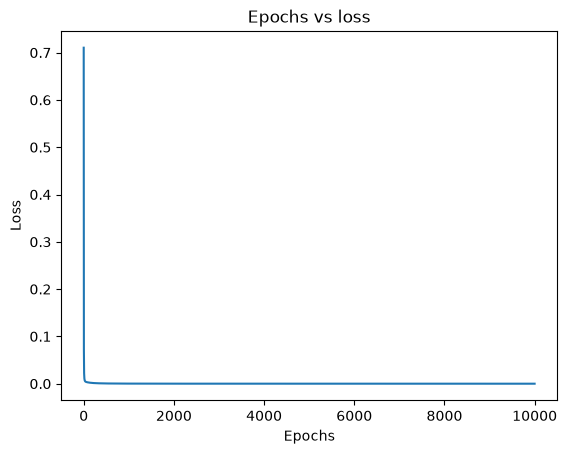

In [13]:
# Plot the loss graph
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Epochs vs loss")
plt.show()

In [14]:
## Predicting on new data
new_messages = ["Congratulations! you have won  free ticket to Bahamas. Call now", "Hey are still meeting today for lunch?"]
new_X = vectorizer.transform(new_messages)
new_X = torch.tensor(new_X.toarray(), dtype = torch.float32)
pred = model(new_X)
print(pred)

tensor([[19.8274],
        [24.9294]], grad_fn=<AddmmBackward0>)


In [15]:
# Use activation function to get the probabilities
pred_new = nn.functional.sigmoid(pred)
print(pred_new)
predicted_labels = (pred_new>0.6).float()
print(predicted_labels)

tensor([[1.],
        [1.]], grad_fn=<SigmoidBackward0>)
tensor([[1.],
        [1.]])


In [16]:
## Performance of the model
## Accuracy, sensitivity, specificity, precision and recall
messages_test = vectorizer.transform(df_test["message"])
X_test = torch.tensor(messages_test.todense(), dtype=torch.float32)
y_test = torch.tensor(df_test['type'].values, dtype=torch.float32).reshape(-1,1)
pred_test = model(X_test)
pred_test_labels = (pred_test>0.8).float()
accuracy = (pred_test_labels == y_test).float().mean()
print(accuracy)


tensor(1.)
